In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
path = r"C:\Users\Noble Adike\Desktop\Coding\KPMG\kpmg-1a\data\harvard\Year 2 (Jun 2023 - May 2024)\BTU_TABS_hourly\48190954_BTU_TABS_hourly.csv"
df_main = pd.read_csv(path)

In [3]:
df_main.head(
)

,Timestamp,BTU10(Z21+22+23+24+25+26+27)_ReturnT (C),BTU10(Z21+22+23+24+25+26+27)_SupplyT (C),BTU11(Z32+33)_ReturnT (C),BTU11(Z32+33)_SupplyT (C),BTU13(Z31)_ReturnT (C),BTU13(Z31)_SupplyT (C),BTU5(Z2+3+4+5)_ReturnT (C),BTU5(Z2+3+4+5)_SupplyT (C),BTU6(Z1)_ReturnT (C),...,BTU13(Z31)_energy (kBTU/h),BTU13(Z31)_flow (GPM),BTU5(Z2+3+4+5)_energy (kBTU/h),BTU5(Z2+3+4+5)_flow (GPM),BTU6(Z1)_energy (kBTU/h),BTU6(Z1)_flow (GPM),BTU7(Z14+15+16+17)_energy (kBTU/h),BTU7(Z14+15+16+17)_flow (GPM),BTU8(Z11+12+13)_energy (kBTU/h),BTU8(Z11+12+13)_flow (GPM)
0,2023-06-01 00:00:00-04:00,22.277669,19.762646,22.632133,19.866175,23.483728,20.735764,20.706846,18.777516,21.876285,...,0.712378,0.115333,2.533518,0.506142,3.536633,0.715769,4.201153,0.763483,3.354210,0.657357
1,2023-06-01 01:00:00-04:00,20.748529,16.846843,21.162681,16.807802,21.533989,16.844679,20.302195,16.813048,20.074290,...,1.202200,0.284671,3.829046,1.218293,5.052960,1.741402,6.001051,1.807530,4.764444,1.512917
2,2023-06-01 02:00:00-04:00,20.371549,17.442606,20.709173,17.403111,21.060666,17.443750,20.223930,17.412087,19.950456,...,0.936709,0.288394,3.079407,1.215540,3.923609,1.743794,4.455045,1.808805,3.471772,1.508629
3,2023-06-01 03:00:00-04:00,20.070366,17.548300,20.312248,17.507920,20.664856,17.543509,20.083252,17.517080,19.772127,...,0.815994,0.291065,2.807449,1.212531,3.477212,1.740623,3.763446,1.804362,2.887461,1.505380
4,2023-06-01 04:00:00-04:00,19.807088,17.547077,19.991587,17.506162,20.347847,17.540971,19.937424,17.517350,19.598049,...,0.739143,0.295703,2.645418,1.211143,3.209704,1.741888,3.335242,1.802975,2.555967,1.509049


In [5]:
len(list(df_main.columns))

29

In [6]:
df_main.isna().sum()

Timestamp                                       0
BTU10(Z21+22+23+24+25+26+27)_ReturnT (C)        0
BTU10(Z21+22+23+24+25+26+27)_SupplyT (C)        0
BTU11(Z32+33)_ReturnT (C)                       0
BTU11(Z32+33)_SupplyT (C)                       0
BTU13(Z31)_ReturnT (C)                          0
BTU13(Z31)_SupplyT (C)                          0
BTU5(Z2+3+4+5)_ReturnT (C)                      0
BTU5(Z2+3+4+5)_SupplyT (C)                      0
BTU6(Z1)_ReturnT (C)                            0
BTU6(Z1)_SupplyT (C)                            0
BTU7(Z14+15+16+17)_ReturnT (C)                  0
BTU7(Z14+15+16+17)_SupplyT (C)                  0
BTU8(Z11+12+13)_ReturnT (C)                     0
BTU8(Z11+12+13)_SupplyT (C)                     0
BTU10(Z21+22+23+24+25+26+27)_energy (kBTU/h)    0
BTU10(Z21+22+23+24+25+26+27)_flow (GPM)         0
BTU11(Z32+33)_energy (kBTU/h)                   0
BTU11(Z32+33)_flow (GPM)                        0
BTU13(Z31)_energy (kBTU/h)                      0


In [7]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 29 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Timestamp                                     8784 non-null   object 
 1   BTU10(Z21+22+23+24+25+26+27)_ReturnT (C)      8784 non-null   float64
 2   BTU10(Z21+22+23+24+25+26+27)_SupplyT (C)      8784 non-null   float64
 3   BTU11(Z32+33)_ReturnT (C)                     8784 non-null   float64
 4   BTU11(Z32+33)_SupplyT (C)                     8784 non-null   float64
 5   BTU13(Z31)_ReturnT (C)                        8784 non-null   float64
 6   BTU13(Z31)_SupplyT (C)                        8784 non-null   float64
 7   BTU5(Z2+3+4+5)_ReturnT (C)                    8784 non-null   float64
 8   BTU5(Z2+3+4+5)_SupplyT (C)                    8784 non-null   float64
 9   BTU6(Z1)_ReturnT (C)                          8784 non-null   f

In [8]:
zero_counts = (df_main == 0).sum()
zero_counts

Timestamp                                          0
BTU10(Z21+22+23+24+25+26+27)_ReturnT (C)           0
BTU10(Z21+22+23+24+25+26+27)_SupplyT (C)           0
BTU11(Z32+33)_ReturnT (C)                          0
BTU11(Z32+33)_SupplyT (C)                          0
BTU13(Z31)_ReturnT (C)                             0
BTU13(Z31)_SupplyT (C)                             0
BTU5(Z2+3+4+5)_ReturnT (C)                         0
BTU5(Z2+3+4+5)_SupplyT (C)                         0
BTU6(Z1)_ReturnT (C)                               0
BTU6(Z1)_SupplyT (C)                               0
BTU7(Z14+15+16+17)_ReturnT (C)                     0
BTU7(Z14+15+16+17)_SupplyT (C)                     0
BTU8(Z11+12+13)_ReturnT (C)                        0
BTU8(Z11+12+13)_SupplyT (C)                        0
BTU10(Z21+22+23+24+25+26+27)_energy (kBTU/h)    4202
BTU10(Z21+22+23+24+25+26+27)_flow (GPM)         4204
BTU11(Z32+33)_energy (kBTU/h)                   4387
BTU11(Z32+33)_flow (GPM)                      

In [9]:
df_main['Timestamp'] = pd.to_datetime(df_main['Timestamp'])
df_main = df_main.set_index('Timestamp')


C:\Users\Noble Adike\AppData\Local\Temp\ipykernel_9464\3611749793.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_main['Timestamp'] = pd.to_datetime(df_main['Timestamp'])


In [10]:
df_main = df_main.sort_index()

In [11]:
temp_cols = [col for col in df_main.columns if 'ReturnT' in col or 'SupplyT' in col]

In [12]:
for col in temp_cols:
    df_main.loc[(df_main[col] < 5) | (df_main[col] > 30), col] = np.nan

In [13]:
df_main[temp_cols].isna().sum()

BTU10(Z21+22+23+24+25+26+27)_ReturnT (C)      0
BTU10(Z21+22+23+24+25+26+27)_SupplyT (C)     29
BTU11(Z32+33)_ReturnT (C)                     0
BTU11(Z32+33)_SupplyT (C)                    62
BTU13(Z31)_ReturnT (C)                       84
BTU13(Z31)_SupplyT (C)                      143
BTU5(Z2+3+4+5)_ReturnT (C)                    0
BTU5(Z2+3+4+5)_SupplyT (C)                  153
BTU6(Z1)_ReturnT (C)                          0
BTU6(Z1)_SupplyT (C)                          1
BTU7(Z14+15+16+17)_ReturnT (C)                0
BTU7(Z14+15+16+17)_SupplyT (C)               70
BTU8(Z11+12+13)_ReturnT (C)                   0
BTU8(Z11+12+13)_SupplyT (C)                   5
dtype: int64

In [14]:
df_raw = pd.read_csv(path, parse_dates=["Timestamp"])
df_raw = df_raw.set_index("Timestamp").sort_index()

In [ ]:
energy_cols = [c for c in df_main.columns if "energy" in c.lower()]
flow_cols   = [c for c in df_main.columns if "flow" in c.lower()]

for col in energy_cols + flow_cols:
    df_main.loc[df_main[col] < 0, col] = np.nan


In [16]:
df_main[energy_cols + flow_cols].isna().sum()

BTU10(Z21+22+23+24+25+26+27)_energy (kBTU/h)    0
BTU11(Z32+33)_energy (kBTU/h)                   0
BTU13(Z31)_energy (kBTU/h)                      0
BTU5(Z2+3+4+5)_energy (kBTU/h)                  0
BTU6(Z1)_energy (kBTU/h)                        0
BTU7(Z14+15+16+17)_energy (kBTU/h)              0
BTU8(Z11+12+13)_energy (kBTU/h)                 0
BTU10(Z21+22+23+24+25+26+27)_flow (GPM)         0
BTU11(Z32+33)_flow (GPM)                        0
BTU13(Z31)_flow (GPM)                           0
BTU5(Z2+3+4+5)_flow (GPM)                       0
BTU6(Z1)_flow (GPM)                             0
BTU7(Z14+15+16+17)_flow (GPM)                   0
BTU8(Z11+12+13)_flow (GPM)                      0
dtype: int64

In [17]:
df_main[temp_cols] = df_main[temp_cols].interpolate(limit=10)

In [18]:
df_main[temp_cols].isna().sum()

BTU10(Z21+22+23+24+25+26+27)_ReturnT (C)     0
BTU10(Z21+22+23+24+25+26+27)_SupplyT (C)     0
BTU11(Z32+33)_ReturnT (C)                    0
BTU11(Z32+33)_SupplyT (C)                    0
BTU13(Z31)_ReturnT (C)                      14
BTU13(Z31)_SupplyT (C)                      18
BTU5(Z2+3+4+5)_ReturnT (C)                   0
BTU5(Z2+3+4+5)_SupplyT (C)                   0
BTU6(Z1)_ReturnT (C)                         0
BTU6(Z1)_SupplyT (C)                         0
BTU7(Z14+15+16+17)_ReturnT (C)               0
BTU7(Z14+15+16+17)_SupplyT (C)               0
BTU8(Z11+12+13)_ReturnT (C)                  0
BTU8(Z11+12+13)_SupplyT (C)                  0
dtype: int64

In [19]:
df_main[temp_cols] = df_main[temp_cols].fillna(method='ffill').fillna(method='bfill')

C:\Users\Noble Adike\AppData\Local\Temp\ipykernel_9464\2858819406.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_main[temp_cols] = df_main[temp_cols].fillna(method='ffill').fillna(method='bfill')


In [20]:
df_main[temp_cols].isna().sum()

BTU10(Z21+22+23+24+25+26+27)_ReturnT (C)    0
BTU10(Z21+22+23+24+25+26+27)_SupplyT (C)    0
BTU11(Z32+33)_ReturnT (C)                   0
BTU11(Z32+33)_SupplyT (C)                   0
BTU13(Z31)_ReturnT (C)                      0
BTU13(Z31)_SupplyT (C)                      0
BTU5(Z2+3+4+5)_ReturnT (C)                  0
BTU5(Z2+3+4+5)_SupplyT (C)                  0
BTU6(Z1)_ReturnT (C)                        0
BTU6(Z1)_SupplyT (C)                        0
BTU7(Z14+15+16+17)_ReturnT (C)              0
BTU7(Z14+15+16+17)_SupplyT (C)              0
BTU8(Z11+12+13)_ReturnT (C)                 0
BTU8(Z11+12+13)_SupplyT (C)                 0
dtype: int64

In [21]:
df_main[energy_cols + flow_cols].describe()


,BTU10(Z21+22+23+24+25+26+27)_energy (kBTU/h),BTU11(Z32+33)_energy (kBTU/h),BTU13(Z31)_energy (kBTU/h),BTU5(Z2+3+4+5)_energy (kBTU/h),BTU6(Z1)_energy (kBTU/h),BTU7(Z14+15+16+17)_energy (kBTU/h),BTU8(Z11+12+13)_energy (kBTU/h),BTU10(Z21+22+23+24+25+26+27)_flow (GPM),BTU11(Z32+33)_flow (GPM),BTU13(Z31)_flow (GPM),BTU5(Z2+3+4+5)_flow (GPM),BTU6(Z1)_flow (GPM),BTU7(Z14+15+16+17)_flow (GPM),BTU8(Z11+12+13)_flow (GPM)
count,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,1.527153,0.703039,0.258133,0.916793,0.606969,0.696816,0.458244,0.794292,0.386609,0.141325,0.437525,0.406272,0.389589,0.313479
std,1.889211,0.895117,0.343331,1.058188,1.036269,0.888592,0.650725,1.152741,0.495565,0.176817,0.461459,0.647699,0.625513,0.522993
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.262030,0.000003,0.000000,0.662149,0.000000,0.031775,0.000000,0.083202,0.000000,0.000000,0.465624,0.000000,0.011477,0.000000
75%,3.089566,1.414202,0.541697,1.607831,1.136124,1.465071,0.997201,1.135998,0.749540,0.302854,0.848849,0.692754,0.451302,0.351383
max,11.481995,6.063663,1.912698,7.065073,7.376943,6.001051,5.262296,3.961151,1.620693,0.495877,1.402453,2.160849,2.032779,1.703869


In [22]:
import numpy as np

# Count inf values per energy/flow column
np.isinf(df_main[energy_cols]).sum()


BTU10(Z21+22+23+24+25+26+27)_energy (kBTU/h)    0
BTU11(Z32+33)_energy (kBTU/h)                   0
BTU13(Z31)_energy (kBTU/h)                      0
BTU5(Z2+3+4+5)_energy (kBTU/h)                  0
BTU6(Z1)_energy (kBTU/h)                        0
BTU7(Z14+15+16+17)_energy (kBTU/h)              0
BTU8(Z11+12+13)_energy (kBTU/h)                 0
dtype: int64

In [23]:
bad_times = df_main.index[np.isinf(df_main["BTU11(Z32+33)_energy (kBTU/h)"])]
print(bad_times[:20])  # show first 20


Index([], dtype='object', name='Timestamp')


In [24]:
df_main = df_main.replace([np.inf, -np.inf], np.nan)


In [25]:
df_main = df_main.dropna(subset=energy_cols)
df_main.isna().sum()

BTU10(Z21+22+23+24+25+26+27)_ReturnT (C)        0
BTU10(Z21+22+23+24+25+26+27)_SupplyT (C)        0
BTU11(Z32+33)_ReturnT (C)                       0
BTU11(Z32+33)_SupplyT (C)                       0
BTU13(Z31)_ReturnT (C)                          0
BTU13(Z31)_SupplyT (C)                          0
BTU5(Z2+3+4+5)_ReturnT (C)                      0
BTU5(Z2+3+4+5)_SupplyT (C)                      0
BTU6(Z1)_ReturnT (C)                            0
BTU6(Z1)_SupplyT (C)                            0
BTU7(Z14+15+16+17)_ReturnT (C)                  0
BTU7(Z14+15+16+17)_SupplyT (C)                  0
BTU8(Z11+12+13)_ReturnT (C)                     0
BTU8(Z11+12+13)_SupplyT (C)                     0
BTU10(Z21+22+23+24+25+26+27)_energy (kBTU/h)    0
BTU10(Z21+22+23+24+25+26+27)_flow (GPM)         0
BTU11(Z32+33)_energy (kBTU/h)                   0
BTU11(Z32+33)_flow (GPM)                        0
BTU13(Z31)_energy (kBTU/h)                      0
BTU13(Z31)_flow (GPM)                           0


In [26]:
df_main[temp_cols].describe()

,BTU10(Z21+22+23+24+25+26+27)_ReturnT (C),BTU10(Z21+22+23+24+25+26+27)_SupplyT (C),BTU11(Z32+33)_ReturnT (C),BTU11(Z32+33)_SupplyT (C),BTU13(Z31)_ReturnT (C),BTU13(Z31)_SupplyT (C),BTU5(Z2+3+4+5)_ReturnT (C),BTU5(Z2+3+4+5)_SupplyT (C),BTU6(Z1)_ReturnT (C),BTU6(Z1)_SupplyT (C),BTU7(Z14+15+16+17)_ReturnT (C),BTU7(Z14+15+16+17)_SupplyT (C),BTU8(Z11+12+13)_ReturnT (C),BTU8(Z11+12+13)_SupplyT (C)
count,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,22.023048,23.121744,22.676441,23.163522,24.104904,24.410500,21.729195,22.876184,21.654124,22.141220,21.523091,22.872341,21.808132,22.529400
std,1.402903,3.066722,1.889533,3.149958,2.255785,3.137487,2.272002,3.766475,1.346730,2.535169,1.275363,3.026268,1.322750,2.700296
min,18.291225,16.275553,18.512833,16.239509,18.829019,16.277575,18.078664,16.242704,17.857059,16.279230,18.119817,16.259680,17.895466,16.186640
25%,21.259852,21.225048,21.360366,21.291453,22.527078,22.582531,19.849529,19.754486,21.141814,20.828937,20.718523,20.999913,21.525618,21.242180
50%,22.240726,22.642618,22.599691,22.633001,24.350533,24.948050,21.044214,21.482300,21.884524,21.800392,21.671416,22.288890,22.097692,22.229686
75%,22.964985,25.946322,24.013804,25.983207,25.608131,26.798364,24.085527,26.912000,22.539369,23.286563,22.411591,25.536193,22.597203,24.521040
max,27.056203,29.994229,28.364208,29.995265,29.996180,29.990832,27.077534,29.998890,25.078243,29.882350,25.111857,29.964006,24.831387,29.909056


In [37]:
df_main[energy_cols + flow_cols].describe()

,BTU10(Z21+22+23+24+25+26+27)_energy (kBTU/h),BTU11(Z32+33)_energy (kBTU/h),BTU13(Z31)_energy (kBTU/h),BTU5(Z2+3+4+5)_energy (kBTU/h),BTU6(Z1)_energy (kBTU/h),BTU7(Z14+15+16+17)_energy (kBTU/h),BTU8(Z11+12+13)_energy (kBTU/h),BTU10(Z21+22+23+24+25+26+27)_flow (GPM),BTU11(Z32+33)_flow (GPM),BTU13(Z31)_flow (GPM),BTU5(Z2+3+4+5)_flow (GPM),BTU6(Z1)_flow (GPM),BTU7(Z14+15+16+17)_flow (GPM),BTU8(Z11+12+13)_flow (GPM)
count,8610.000000,8610.000000,8610.000000,8610.000000,8610.000000,8610.000000,8610.000000,8610.000000,8610.000000,8610.000000,8610.000000,8610.000000,8610.000000,8610.000000
mean,1.645878,0.752554,0.245501,0.877886,0.621054,0.750067,0.525655,0.849334,0.399138,0.132150,0.481591,0.404643,0.417559,0.351594
std,2.036266,0.954880,0.355995,1.001144,1.125843,0.949752,0.718299,1.200706,0.498822,0.176208,0.497805,0.671149,0.615766,0.550735
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.272372,0.000779,0.000000,0.671498,0.000000,0.091250,0.000000,0.109734,0.001138,0.000000,0.555184,0.000000,0.038709,0.000000
75%,3.455017,1.555813,0.529743,1.489501,1.311670,1.568234,1.200762,1.273656,0.773082,0.302489,0.889573,0.661506,0.642860,0.453225
max,14.736573,6.617710,2.577889,8.730129,9.753332,7.447368,5.937321,3.974920,1.615085,0.508405,1.728978,2.358933,1.955438,1.814199


In [27]:
zero_pct = (df_main["BTU11(Z32+33)_energy (kBTU/h)"] == 0).mean() * 100
print(f"{zero_pct:.2f}% of hours are zero")

49.94% of hours are zero


<Axes: >

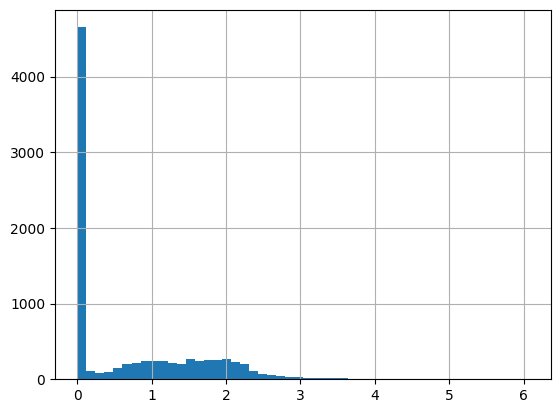

In [28]:
df_main["BTU11(Z32+33)_energy (kBTU/h)"].hist(bins=50)


In [29]:
scaler = StandardScaler()
df_main[temp_cols + energy_cols + flow_cols] = scaler.fit_transform(df_main[temp_cols + energy_cols + flow_cols]) 

In [30]:
df_main[temp_cols].head()

,BTU10(Z21+22+23+24+25+26+27)_ReturnT (C),BTU10(Z21+22+23+24+25+26+27)_SupplyT (C),BTU11(Z32+33)_ReturnT (C),BTU11(Z32+33)_SupplyT (C),BTU13(Z31)_ReturnT (C),BTU13(Z31)_SupplyT (C),BTU5(Z2+3+4+5)_ReturnT (C),BTU5(Z2+3+4+5)_SupplyT (C),BTU6(Z1)_ReturnT (C),BTU6(Z1)_SupplyT (C),BTU7(Z14+15+16+17)_ReturnT (C),BTU7(Z14+15+16+17)_SupplyT (C),BTU8(Z11+12+13)_ReturnT (C),BTU8(Z11+12+13)_SupplyT (C)
Timestamp,,,,,,,,,,,,,,
2023-06-01 00:00:00-04:00,0.181506,-1.095401,-0.023451,-1.046850,-0.275386,-1.171302,-0.450003,-1.088259,0.164973,-1.010673,0.323034,-1.006002,0.303808,-1.049674
2023-06-01 01:00:00-04:00,-0.908538,-2.046243,-0.801175,-2.017830,-1.139764,-2.411564,-0.628116,-1.609856,-1.173155,-2.085569,-0.788119,-1.998526,-1.123969,-2.145093
2023-06-01 02:00:00-04:00,-1.177267,-1.851965,-1.041200,-1.828830,-1.349602,-2.220614,-0.662566,-1.450802,-1.265112,-1.851861,-1.067120,-1.801693,-1.401958,-1.924193
2023-06-01 03:00:00-04:00,-1.391966,-1.817498,-1.251277,-1.795555,-1.525076,-2.188816,-0.724487,-1.422924,-1.397536,-1.811293,-1.319428,-1.767279,-1.637027,-1.885682
2023-06-01 04:00:00-04:00,-1.579642,-1.817897,-1.420990,-1.796113,-1.665616,-2.189625,-0.788676,-1.422853,-1.526803,-1.811286,-1.523919,-1.767761,-1.833537,-1.886809
